In [10]:
from lib.dds import *
from lib.time import *
from lib.dataplot import *
from lib.system import *
from lib.bug import *
from lib.pot_field import *
from collections import deque
import numpy as np
import cv2
import math
import time

#init plots
PLTS_N = 10
plts = [DataPlotter() for i in range(PLTS_N)]

plts[0] = DataPlotter()
plts[0].set_x("Time ")
plts[0].add_y("posZ", "Position Z")

plts[1] = DataPlotter()
plts[1].set_x("Time ")
plts[1].add_y("posX", "Position X")

plts[2] = DataPlotter()
plts[2].set_x("Time")
plts[2].add_y("ang", "Rotation")

plts[3] = DataPlotter()
plts[3].set_x("Time")
plts[3].add_y("velZ", "Velocity Z")

plts[4] = DataPlotter()
plts[4].set_x("Time")
plts[4].add_y("velX", "Velocity X")

plts[5] = DataPlotter()
plts[5].set_x("Time")
plts[5].add_y("velAng", "Rotational Velocity")

plts[6] = DataPlotter()
plts[6].set_x("Time")
plts[6].add_y("w1", "FrontLeft Motor")

plts[7] = DataPlotter()
plts[7].set_x("Time")
plts[7].add_y("w2", "FrontRight Motor")

plts[8] = DataPlotter()
plts[8].set_x("Time")
plts[8].add_y("w3", "ReerRight Motor")

plts[9] = DataPlotter()
plts[9].set_x("Time")
plts[9].add_y("w4", "ReerLeft Motor")

dds = DDS()
dds.start()

#subscribe to robot sensors
dds.subscribe(["posZ", "posX", "ang", "velZ","velX","velAng", "colliding", "obstacle_pos_z", "obstacle_pos_x"])

#init map
width, height = 1000, 1000
imm = np.zeros((height, width, 3), dtype=np.uint8)
map_scale = 25
center_pixel_z = height // 2
center_pixel_x = width // 2

#init obstacle queue
TTL = 4.0
valid_points = deque()

#set target position
target_pos_z = 20
target_pos_x = 5
dds.publish("target_z", target_pos_z, dds.DDS_TYPE_FLOAT)
dds.publish("target_x", target_pos_x, dds.DDS_TYPE_FLOAT)
target_pixel_x = target_pos_x * map_scale + center_pixel_x
target_pixel_z = target_pos_z * map_scale + center_pixel_z

#init controllers
robot = MecanumController(2.5, 2, 50, 0.15, 1)
pos_con = PositionController(0.5, 0.5, 0.1,4)
bug = Bug(0.67, 2.5, 3)
bugging = False
pot_field = PotField(0.5, 10, 3, target_pos_z, target_pos_x) #k_att, k_rep, rho_0

t = Time()
t.start()

while t.get() < 120:
    delta_t = t.elapsed()
    now = time.time()

    #read sensors
    robot_pos_z = dds.wait("posZ")
    robot_pos_x = dds.wait("posX")
    ang = dds.wait("ang")
    velZ = dds.wait("velZ")
    velX = dds.wait("velX")
    velAng = dds.wait("velAng")
    is_colliding = dds.read("colliding")

    #append robot current position
    #valid_points.append((now + TTL + 100, robot_pos_x, robot_pos_z, (255, 0, 0)))

    #append new obstacles
    if is_colliding:
        obstacle_pos_z = dds.read("obstacle_pos_z")
        obstacle_pos_x = dds.read("obstacle_pos_x")
        bug.add_point([robot_pos_z, robot_pos_x],[obstacle_pos_z, obstacle_pos_x])
        valid_points.append((now + TTL, obstacle_pos_x, obstacle_pos_z, (0, 0, 255)))

    #pop expired points
    valid_points = [p for p in valid_points if p[0] >= now]

    #check if robot should be bugging
    if abs(velZ) < 0.15 and abs(velX) < 0.15 and t.get() > 5 and (not (bugging)) and math.hypot(robot_pos_x - target_pos_x, robot_pos_z - target_pos_z) > 2:
        bug.start([robot_pos_z,robot_pos_x],[target_pos_z,target_pos_x])
        bugging = True

    bug.clear_flag()

    #temporary target
    if bugging:
        bugging, robot_target_pos_z, robot_target_pos_x = bug.detour([robot_pos_z,robot_pos_x])
    else:
        robot_target_pos_z, robot_target_pos_x = pot_field.evaluate(robot_pos_z, robot_pos_x, valid_points)
    dds.publish("temp_target_z", robot_target_pos_z, dds.DDS_TYPE_FLOAT)
    dds.publish("temp_target_x", robot_target_pos_x, dds.DDS_TYPE_FLOAT)

    #conversion to pixel coordinates
    robot_target_pixel_z = int(robot_target_pos_z * map_scale) + center_pixel_z
    robot_target_pixel_x = int(robot_target_pos_x * map_scale) + center_pixel_x
    robot_pixel_z = int(robot_pos_z * map_scale) + center_pixel_z
    robot_pixel_x = int(robot_pos_x * map_scale) + center_pixel_x

    #print points
    imm.fill(0)
    cv2.arrowedLine(imm, (robot_pixel_x, robot_pixel_z), (robot_target_pixel_x, robot_target_pixel_z), (0, 255, 0), 3)
    for expire, x, z, color in valid_points:
        cv2.circle(imm, (int(x * map_scale) + center_pixel_x, int(z * map_scale) + center_pixel_z), 2, color, -1)
    cv2.imshow("map", imm)

    #evaluate engine forces
    target_p = np.array([robot_target_pos_z - robot_pos_z, robot_target_pos_x - robot_pos_x, 10 - ang])
    vel_target = pos_con.evaluate(delta_t,target_p)
    vel_sensor = np.array([velZ, velX, velAng])
    robot.set_target(vel_target)
    w = robot.evaluate(delta_t, vel_sensor)

    #publish engine forces
    dds.publish("w1", w[0], dds.DDS_TYPE_FLOAT)
    dds.publish("w2", w[1], dds.DDS_TYPE_FLOAT)
    dds.publish("w3", w[2], dds.DDS_TYPE_FLOAT)
    dds.publish("w4", w[3], dds.DDS_TYPE_FLOAT)

    #update plots
    plts[0].append_x(t.get())
    plts[0].append_y("posZ", robot_pos_z)

    plts[1].append_x(t.get())
    plts[1].append_y("posX", robot_pos_x)

    plts[2].append_x(t.get())
    plts[2].append_y("ang", ang)

    plts[3].append_x(t.get())
    plts[3].append_y("velZ", velZ)

    plts[4].append_x(t.get())
    plts[4].append_y("velX", velX)

    plts[5].append_x(t.get())
    plts[5].append_y("velAng", velAng)

    plts[6].append_x(t.get())
    plts[6].append_y("w1", w[0])

    plts[7].append_x(t.get())
    plts[7].append_y("w2", w[1])

    plts[8].append_x(t.get())
    plts[8].append_y("w3", w[2])

    plts[9].append_x(t.get())
    plts[9].append_y("w4", w[3])

    #stop condition
    if cv2.waitKey(1) == ord('q'):
        break

#stop the robot
dds.publish("w1", 0, dds.DDS_TYPE_FLOAT)
dds.publish("w2", 0, dds.DDS_TYPE_FLOAT)
dds.publish("w3", 0, dds.DDS_TYPE_FLOAT)
dds.publish("w4", 0, dds.DDS_TYPE_FLOAT)


cv2.destroyAllWindows()
dds.stop()

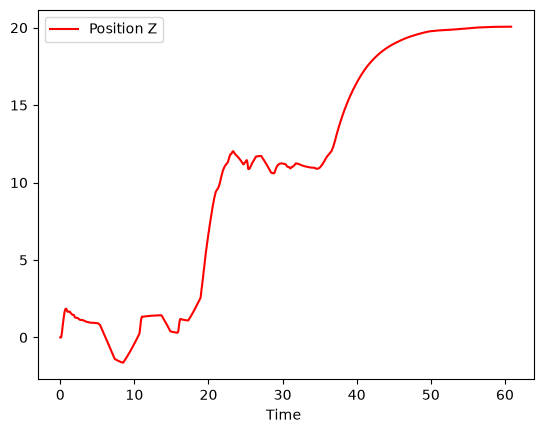

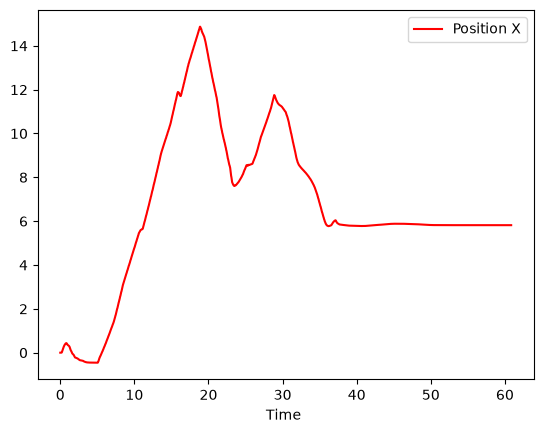

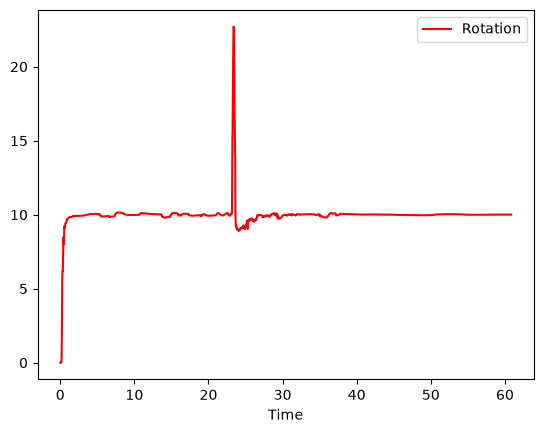

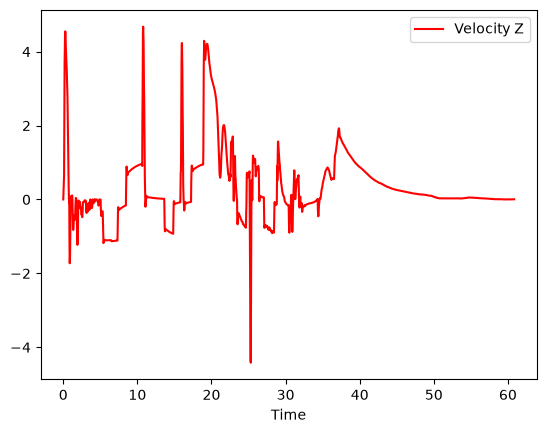

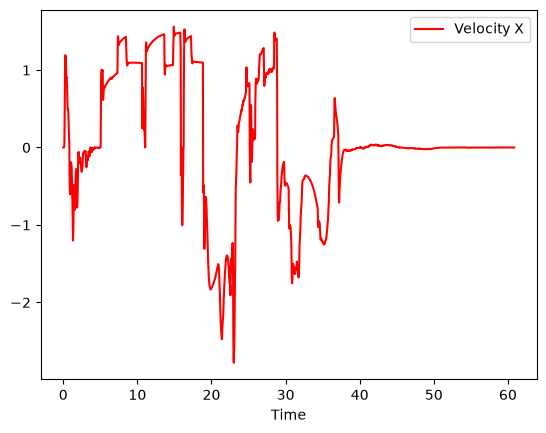

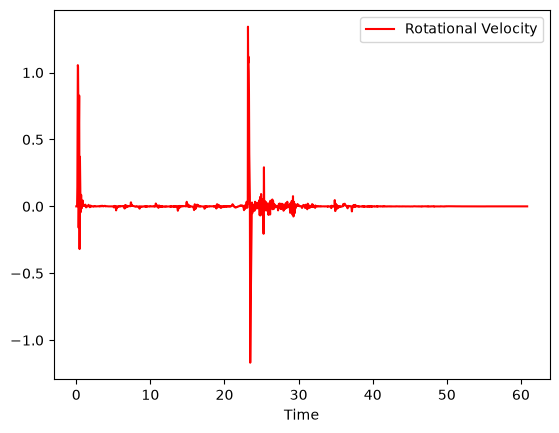

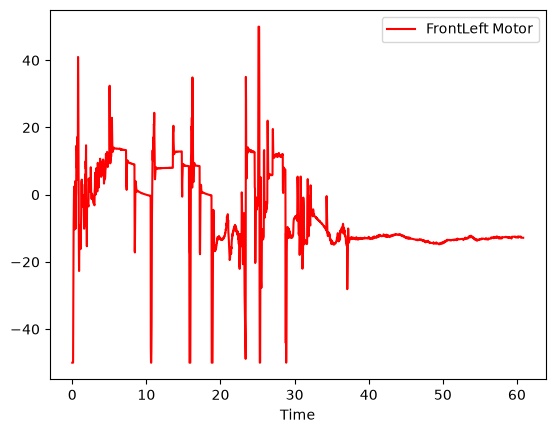

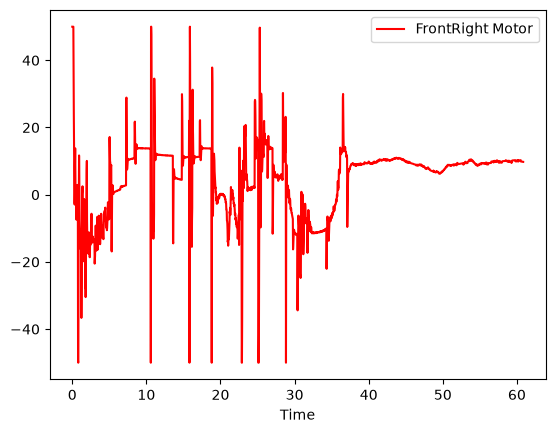

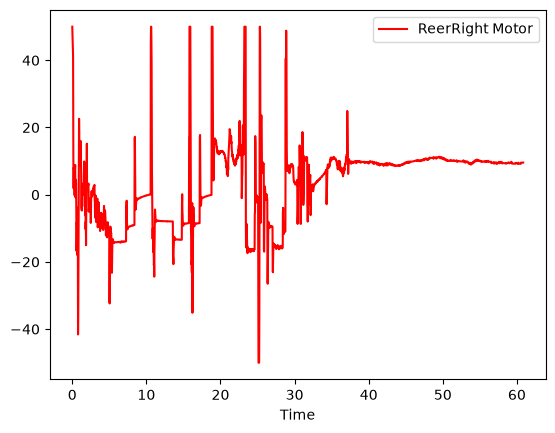

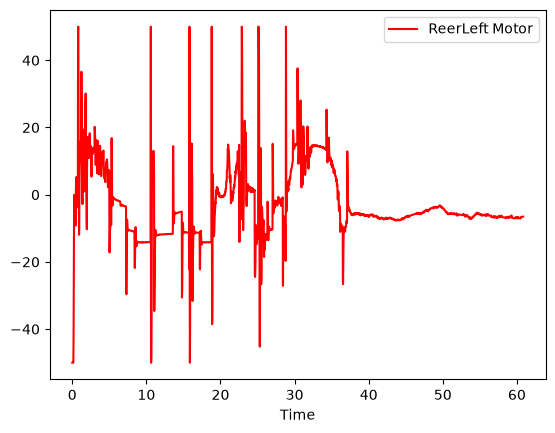

In [11]:
#print plots

for p in plts:
    p.plot()